UCI Diabetes Dataset Sample:
    Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0      172             84             45      393  42.04   
1      162            110             19       84  34.03   
2       84             90             46      165  36.34   
3      176             82             18      243  39.31   
4      141            117             33      258  31.46   

   DiabetesPedigreeFunction  Age  Outcome  
0                      1.10   62        1  
1                      0.30   64        1  
2                      2.49   22        0  
3                      1.31   75        0  
4                      1.53   55        1  

Pima Indians Diabetes Dataset Sample:
    Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0       86             50             32      105  33.58   
1      195             57             53      152  41.68   
2      153             78             11      202  29.71   
3       78             54             47       81  22.34   
4    

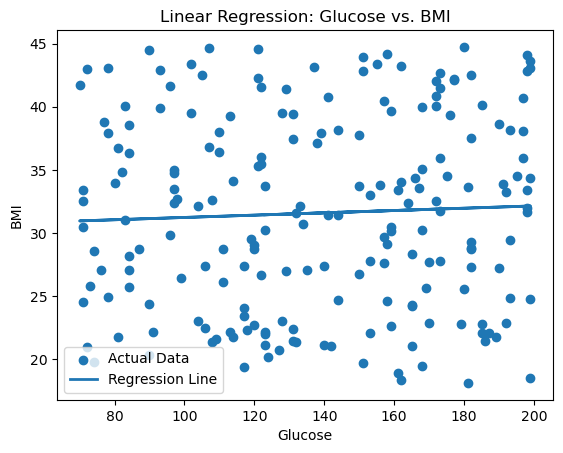


Linear Regression (Predicting BMI using Glucose):
R2 Score: 0.0001


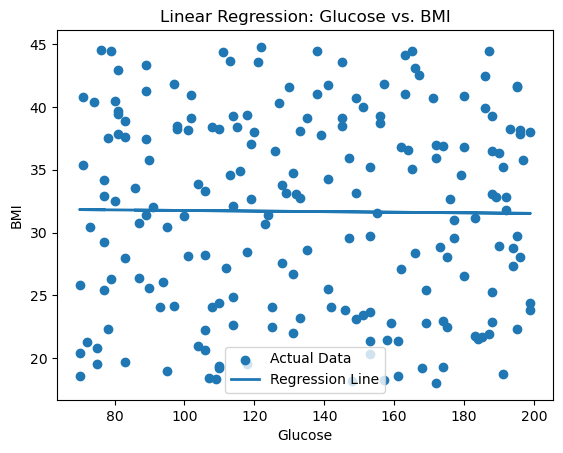


Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.5000

Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.5250


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

np.random.seed(42)

n = 200

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(70, 200, n),
    "BloodPressure": np.random.randint(50, 120, n),
    "SkinThickness": np.random.randint(10, 60, n),
    "Insulin": np.random.randint(20, 400, n),
    "BMI": np.round(np.random.uniform(18, 45, n), 2),
    "DiabetesPedigreeFunction": np.round(np.random.uniform(0.1, 2.5, n), 2),
    "Age": np.random.randint(21, 80, n),
    "Outcome": np.random.randint(0, 2, n)
})

pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(70, 200, n),
    "BloodPressure": np.random.randint(50, 120, n),
    "SkinThickness": np.random.randint(10, 60, n),
    "Insulin": np.random.randint(20, 400, n),
    "BMI": np.round(np.random.uniform(18, 45, n), 2),
    "DiabetesPedigreeFunction": np.round(np.random.uniform(0.1, 2.5, n), 2),
    "Age": np.random.randint(21, 80, n),
    "Outcome": np.random.randint(0, 2, n)
})

uci_diabetes.to_csv("uci_diabetes_3.csv", index=False)
pima_diabetes.to_csv("pima_diabetes_3.csv", index=False)

print("UCI Diabetes Dataset Sample:\n", uci_diabetes.head())
print("\nPima Indians Diabetes Dataset Sample:\n", pima_diabetes.head())

def linear_regression_analysis(df, x_column, y_column):
    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)
    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column}):")
    print(f"R2 Score: {r2:.4f}")

    plt.scatter(X, Y, label="Actual Data")
    plt.plot(X, Y_pred, linewidth=2, label="Regression Line")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs. {y_column}")
    plt.legend()
    plt.show()

linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

def logistic_regression_analysis(df, features, target):
    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression (Predicting {target} using {features}):")
    print(f"Accuracy Score: {accuracy:.4f}")

features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)